In [1]:
import json
import math
import matplotlib.pyplot as plt
from gboml import GbomlGraph
import numpy as np
import pandas as pd

In [2]:
time=np.arange(8760)
start_time=144
end_time=312

In [3]:
parameters_vector = list(range(0,21))

In [4]:
with open("4_All_evol.gboml", "r") as f:
    template=f.read()
for k in parameters_vector:
    new=template.format(k=k)
    filename=f"capex_opex_evol/4_All_evol_{k}.gboml"
    with open(filename,"w") as f:
        f.write(new)

In [5]:
import glob
import os
from IPython.display import clear_output

os.makedirs("outputs", exist_ok=True)

files = glob.glob("capex_opex_evol/4_All_evol_*.gboml")

for file in files:
    name = os.path.basename(file).replace('.gboml', '')
    output_file = f"outputs/{name}_output"
    cmd = f"gboml --gurobi {file} --json --output {output_file}"
    print("Running:", cmd)
    !{cmd}
    clear_output()

In [6]:
HKT_capacity_evolution = []
battery_capacity_evolution = []
solar_capacity_evolution = []
wind_of_capacity_evolution = []
objective = []
axis_vector = np.array([1+k*0.05 for k in parameters_vector])
for k in parameters_vector:
    file_name = f"outputs/4_All_evol_{k}_output.json"
    with open(file_name) as json_file:
        solar_wind_tidal_solution = json.load(json_file)
        HKT_capacity_evolution.append(solar_wind_tidal_solution["solution"]["elements"]["tidal"]["variables"]["capacity"]["values"][0])
        battery_capacity_evolution.append(solar_wind_tidal_solution["solution"]["elements"]["battery"]["variables"]["capacity"]["values"][0])
        solar_capacity_evolution.append(solar_wind_tidal_solution["solution"]["elements"]["solar_pv"]["variables"]["capacity"]["values"][0])
        wind_of_capacity_evolution.append(solar_wind_tidal_solution["solution"]["elements"]["wind_offshore"]["variables"]["capacity"]["values"][0])
        objective.append(solar_wind_tidal_solution["solution"]["objective"])

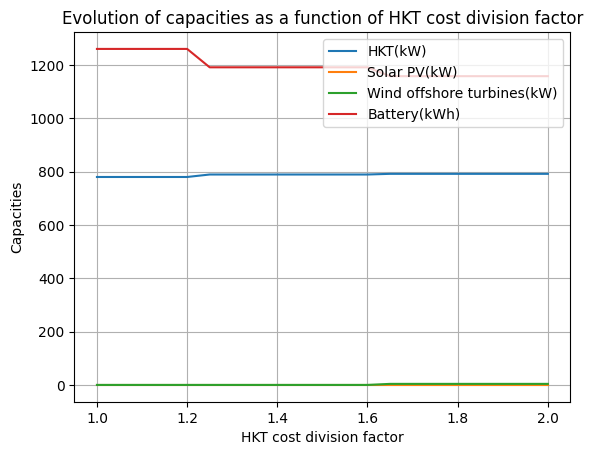

In [7]:
plt.plot(axis_vector,HKT_capacity_evolution)
plt.plot(axis_vector,solar_capacity_evolution)
plt.plot(axis_vector,wind_of_capacity_evolution)
plt.plot(axis_vector,battery_capacity_evolution)
plt.title('Evolution of capacities as a function of HKT cost division factor')
plt.xlabel('HKT cost division factor')
plt.ylabel('Capacities')
plt.legend(["HKT(kW)","Solar PV(kW)","Wind offshore turbines(kW)","Battery(kWh)"])
plt.grid()
plt.show()

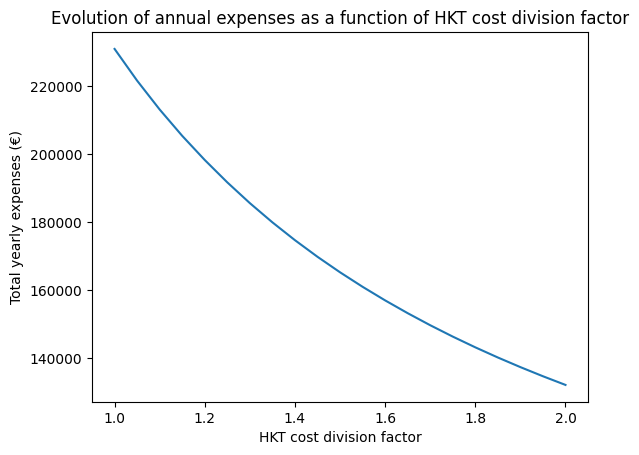

In [8]:
plt.plot(axis_vector,objective)
plt.title('Evolution of annual expenses as a function of HKT cost division factor')
plt.xlabel('HKT cost division factor')
plt.ylabel('Total yearly expenses (€)')
plt.show()